### **RNN (순환 신경망)**

- 이전 시점의 정보를 현재 시점의 계산에 반영하는 구조

    - 첫번째 입력
        - 초기 상태(h_0 = 0)와 입력에 대한 상태(h_1)로 계산
    - 두번째 입력
        - 이전의 상태(h_1)와 결합해서 계산 (h_2)
    - 세번째 입력
        - 이전의 상태(h_2)와 결합해서 계산 (h_3)
    - 반복 작업이 완료되었을 때
        - 마지막 상태(h_t) 생성 → 모든 과거의 정보를 결합해놓은 상태

---
<br>

- **parameter**

    - `input_size`
        - 각 시점(레이어)에서 입력 feature 수
    - `hidden_size`
        - 은닉층(출력)의 크기
    - `num_layers`
        - default : 1
        - RNN 층의 개수 (층이 깊어질수록 복잡한 패턴을 발생)
        - 층의 개수가 늘어날수록 시간은 증가하고 과적합의 위험성이 존재
        - 보통 1~3 정도 사용, 1부터 개수를 1씩 증가시키면서 사용
    - `nonlinearity`
        - default : `tanh`
        - 비선형 활성화 함수를 선택
    - `batch_first`
        - default : False
        - 입력 tensor에서 첫번째 차원이 batch인지 여부
    - `bias`
        - default : True
        - 각 가중치의 절편(편향) 항을 추가할지 여부
    - `dropout`
        - default : 0.0
        - 층 사이 Dropout의 적용 비율 → 층이 2개 이상인 경우에만 사용
    - `bidirectional`
        - default : False
        - 양방향 RNN을 사용할지 여부 (순방향은 기본, 역방향을 사용할 것인가?)

<br>

---

<br>

- **parameter 설정 시 유의할 점**
    - `hidden_size`
        - 너무 적은 경우라면 정보가 부족, 너무 큰 경우라면 과적합
        - 일반적으로는 32, 64, 128 사용
    - `num_layers`
        - 시간의 복잡도에 따라서 1~3 정도를 사용
        - 1부터 테스트를 돌려서 교차 검증
    - `nonlinearity`
        - 일반적으로 `tanh`을 사용
        - `relu`를 사용하면 시간이 감소하지만 발산의 위험성이 존재
    - `dropout`
        - 층이 2개 이상인 경우에만 사용
        - 과적합 방지를 위해 사용하며, 0.2 ~ 0.5 사용

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
# 랜덤 시드 고정

np.random.seed(42)
torch.manual_seed(42)

In [3]:
# 노이즈를 포함한 연ㄴ속성을 가진 sin 곡선을 생성

x = torch.arange(3000).float()
y = torch.sin(2 * math.pi * 0.02 * x) + 0.05 * torch.randn(3000)

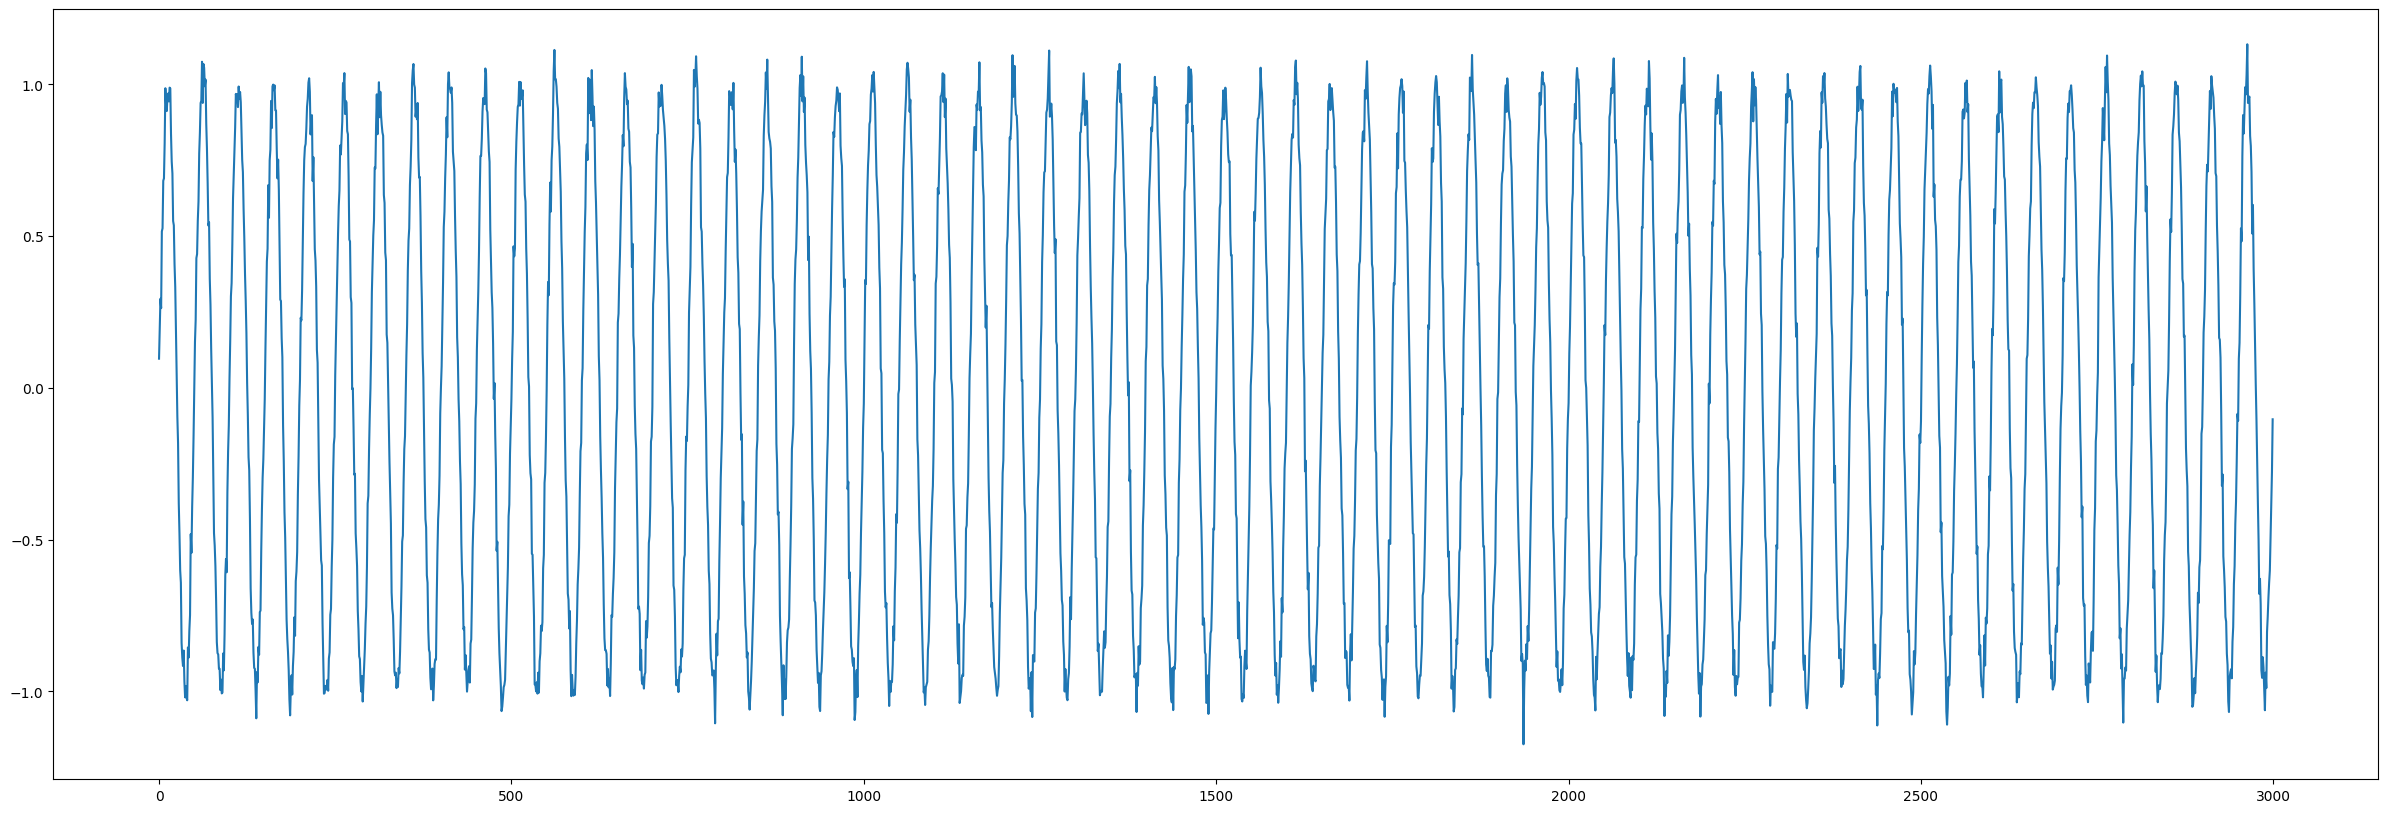

In [4]:
plt.figure(figsize=(30, 10))
plt.plot(x, y)
plt.show()

In [5]:
# train test split
train_size = int(0.8 * len(x))
print(train_size)

# X_train = x[:train_size]
X_train = y[:train_size]
# X_test = x[train_size:]
X_test = y[train_size:]

2400


In [6]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train.reshape(-1, 1))
X_test_sc = scaler.transform(X_test.reshape(-1, 1))

In [7]:
X_train_sc

array([[ 0.13549958],
       [ 0.28142013],
       [ 0.41417719],
       ...,
       [-0.56898224],
       [-0.31882725],
       [-0.10808127]], shape=(2400, 1))

In [8]:
X_train_tensor = torch.tensor(X_train_sc, dtype = torch.float32)
X_test_tensor = torch.tensor(X_test_sc, dtype=torch.float32)

In [9]:
X_train_tensor.shape

torch.Size([2400, 1])

In [10]:
# Tensor Data를 배치가 존재하는 3차원 데이터로 변환

X_train_tensor = X_train_tensor.unsqueeze(0)
X_test_tensor = X_test_tensor.unsqueeze(0)

X_train_tensor.shape

torch.Size([1, 2400, 1])

In [11]:
class RNN_Model(nn.Module):
    def __init__(self):
        super(RNN_Model, self).__init__()
        self.rnn = nn.RNN(
            input_size = 1,
            hidden_size = 64,
            num_layers = 1,
            batch_first = True,
            dropout = 0.0,
            nonlinearity = 'tanh',
            bidirectional = False
        )
        self.linear = nn.Linear(64, 1)
    
    def forward(self, x):
        # RNN 모델에서 2개의 데이터를 되돌려준다.
            # 첫번째 데이터: 모든 시점에서 은닉층의 값
            # 두번째 데이터: 마지막 시점에서 은닉층의 값 → 층이 존재하는 경우 마지막 층의 값을 추출
        out, h_n = self.rnn(x)
        result = self.linear(h_n[-1])
        return result

In [12]:
model = RNN_Model()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)

### **DataLoader**
- Pytorch에서 Dataset들을 배치 단위로 효율적으로 꺼내주는 반복자
- 반복 학습 루트에 맞는 형태의 데이터셋을 공급해주는 역할

- **parameter**
    - `batch_size`
        - Dataset들을 모아서 Tensor의 형태로 묶어준다.
    - `shuffle`
        - epoch마다 데이터의 순서를 랜덤하게 변경
    - `drop_last`
        - window(구간)에 맞는 구간을 나눠주고 마지막 구간에서 데이터가 꽉 채워지지 않는다면 해당 batch를 제거
    - `pin_memory`
        - GPU 사용시 True로 변경하면 CPU → GPU 전송이 빨라짐

In [13]:
# Custom Dataset 클래스 정의

class WindowDataset(Dataset):
    def __init__(self, _data, _window):
        # _data: 시계열 데이터
        # _window : 구간 설정
        self.data = _data
        self.window = _window
        # 유효 샘플의 개수 계산
        # 입력 데이터: 전체 길이 - window 크기
        self.n = len(self.data) - self.window
    # __len__ 메서드: 데이터셋의 크기를 반환
    # __getitem__ 메서드: 인덱스에 해당하는 샘플을 반환
    # 특수 메서드: DataLoader가 데이터셋에서 데이터를 불러올 때 자동으로 호출
    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        # DataLoader 실제로 입력된 데이터들을 슬라이스해서 가지고 가는 함수
        x = self.data[ idx : idx + self.window ]
        y = self.data[ idx + self.window ]
        return x, y

In [14]:
window = 10
train_ds = WindowDataset(X_train_tensor.squeeze(0), window)

In [15]:
len(X_train_tensor.squeeze(0))

2400

In [16]:
len(train_ds)

2390

In [17]:
train_ds.__getitem__(0)

(tensor([[0.1355],
         [0.2814],
         [0.4142],
         [0.3706],
         [0.7275],
         [0.7422],
         [0.9629],
         [0.9741],
         [1.1385],
         [1.3934]]),
 tensor([1.3145]))

In [18]:
batch_size = 10
x_list = []
y_list = []

for i in range(len(train_ds)):
    if i == 10:
        break
    x, y = train_ds[i]
    x_list.append(x)
    y_list.append(y)

In [19]:
train_dl = DataLoader(
    train_ds,
    batch_size = 64,
    drop_last=True,
    shuffle=True
)

test_dl = DataLoader(
    WindowDataset(X_test_tensor.squeeze(0), window),
    batch_size=64,
    drop_last=True,
    shuffle=False
)

In [20]:
# 반복 학습

train_loss_list = []
test_loss_list = []

for epoch in range(20):
    model.train()

    running = 0.0
    n_seen = 0

    for x, y in train_dl:
        x = x.float()
        y = y.float()

        # RNN 모델에 입력(x)을 넣어서 예측값(yhat)을 얻는다.
        yhat = model(x)

        loss = criterion(yhat, y)
        optimizer.zero_grad()
        loss.backward()

        # 미분값 폭주 방지
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        running += loss.item() * x.size(0)
        n_seen += x.size(0)
    
    train_loss = running / max(1, n_seen)
    train_loss_list.append(train_loss)
    print(f'Epoch {epoch+1}, Train Loss: {round(train_loss, 8)}')
        

Epoch 1, Train Loss: 0.1003061
Epoch 2, Train Loss: 0.01078203
Epoch 3, Train Loss: 0.01074139
Epoch 4, Train Loss: 0.01088122
Epoch 5, Train Loss: 0.00999281
Epoch 6, Train Loss: 0.00945274
Epoch 7, Train Loss: 0.01010241
Epoch 8, Train Loss: 0.01187643
Epoch 9, Train Loss: 0.0086853
Epoch 10, Train Loss: 0.00911269
Epoch 11, Train Loss: 0.00888443
Epoch 12, Train Loss: 0.00872169
Epoch 13, Train Loss: 0.00930919
Epoch 14, Train Loss: 0.00947885
Epoch 15, Train Loss: 0.009615
Epoch 16, Train Loss: 0.00855243
Epoch 17, Train Loss: 0.00901465
Epoch 18, Train Loss: 0.00884158
Epoch 19, Train Loss: 0.00926785
Epoch 20, Train Loss: 0.00986589


In [21]:
model.eval()
preds = []
trues = []

with torch.no_grad():
    for x, y in test_dl:
        x = x.float()
        y = y.float()
        pred = model(x)
        preds.append(pred)
        trues.append(y)

In [22]:
torch.cat(preds, 0).squeeze(-1)

tensor([ 1.3367e+00,  1.4254e+00,  1.3663e+00,  1.3664e+00,  1.3746e+00,
         1.4006e+00,  1.2609e+00,  1.2094e+00,  1.1830e+00,  9.7500e-01,
         7.4648e-01,  6.1908e-01,  4.4696e-01,  2.2081e-01,  1.5826e-01,
        -1.0718e-02, -2.6357e-01, -4.2139e-01, -5.2290e-01, -7.0637e-01,
        -8.4316e-01, -9.7160e-01, -1.0985e+00, -1.2393e+00, -1.3609e+00,
        -1.3993e+00, -1.3441e+00, -1.4208e+00, -1.3976e+00, -1.4603e+00,
        -1.3571e+00, -1.3036e+00, -1.2287e+00, -1.1296e+00, -9.7528e-01,
        -9.0224e-01, -6.4106e-01, -5.1300e-01, -3.3688e-01, -1.2366e-01,
         1.0907e-01,  2.7927e-01,  5.0721e-01,  6.9150e-01,  7.2070e-01,
         8.6453e-01,  1.0349e+00,  1.0924e+00,  1.1448e+00,  1.2365e+00,
         1.3771e+00,  1.3312e+00,  1.4134e+00,  1.4045e+00,  1.3677e+00,
         1.3010e+00,  1.2699e+00,  1.2551e+00,  1.1468e+00,  1.0384e+00,
         8.7281e-01,  6.4552e-01,  4.8092e-01,  3.6371e-01,  1.2929e-01,
         3.6302e-02, -1.6615e-01, -4.3648e-01, -6.1

In [23]:
preds = torch.cat(preds, 0).squeeze(-1).numpy()
trues = torch.cat(trues, 0).squeeze(-1).numpy()

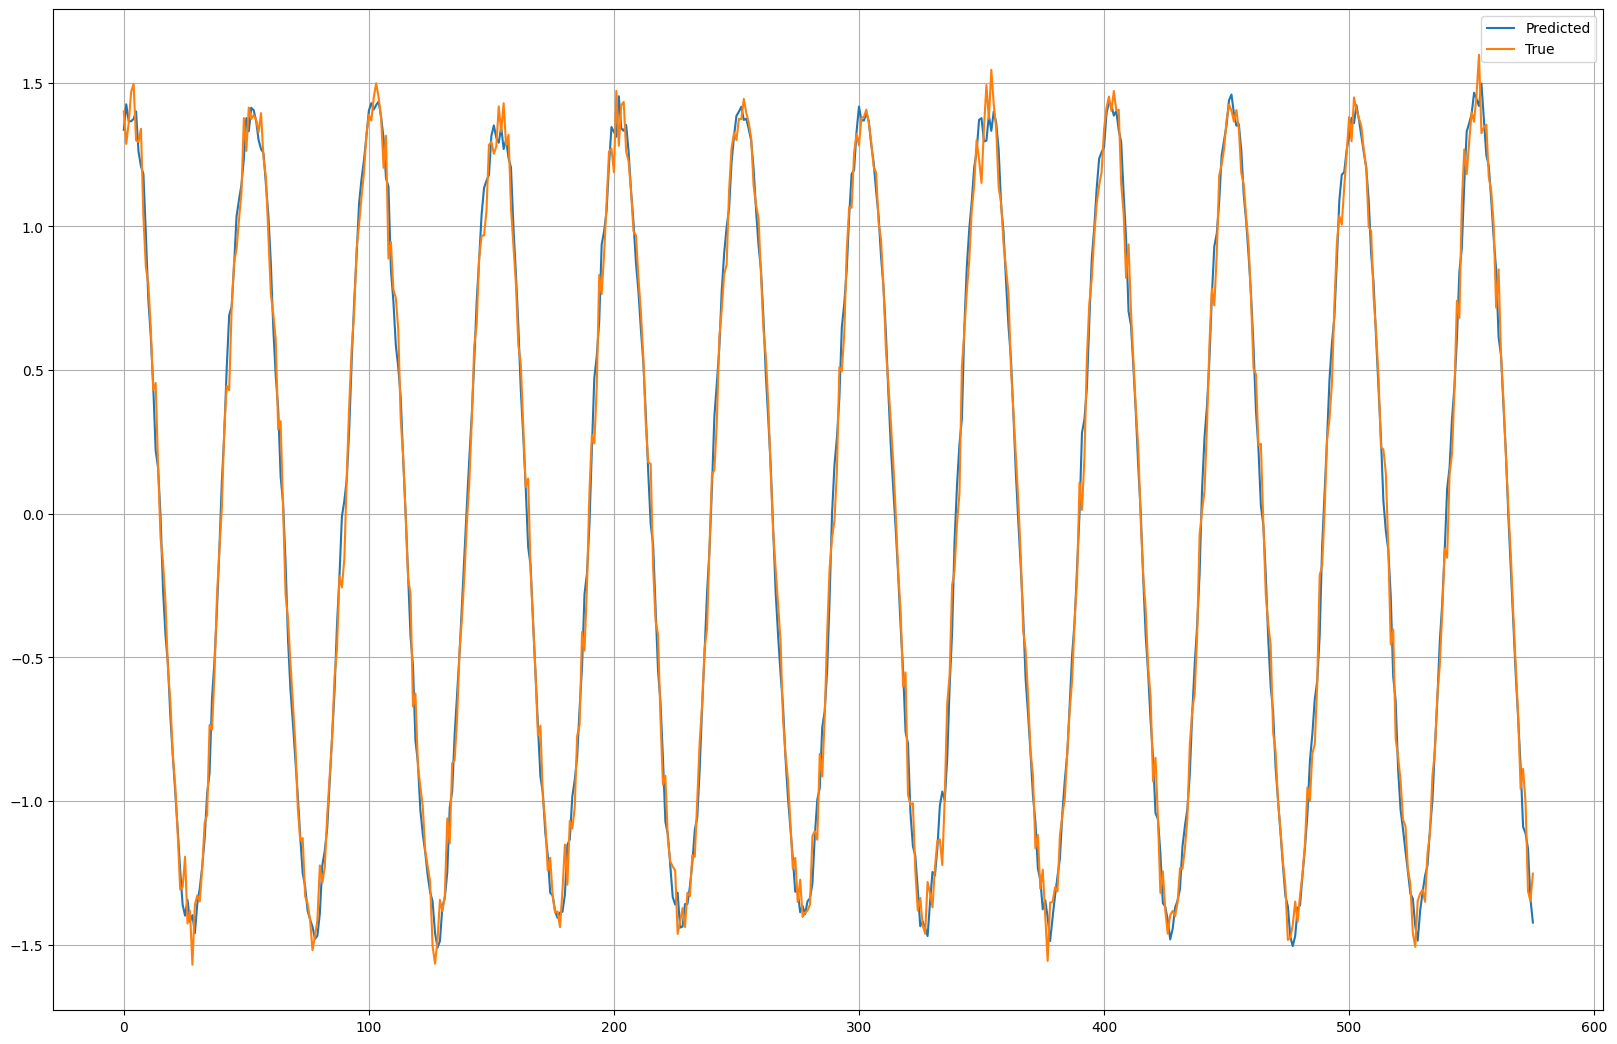

In [24]:
plt.figure(figsize=(20, 13))
plt.plot(preds[:1000], label='Predicted')
plt.plot(trues[:1000], label = 'True')
plt.legend()
plt.grid()
plt.show()